In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns; sns.set()
import matplotlib.pyplot as plt
import pandas as pd
import matplotlib.cm as cm
import matplotlib.colors as mcolors
import torch as pt
from umap import UMAP
import umap.plot

/doctorai/marinafr/progs/miniconda3/envs/airr_atlas/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
df = pd.read_csv('<UPDATE_PATH>'  # TODO: update path to your data, sep=';')

df['v_family'] = df['v_call'].str.split(r'[-/]').str[0]
df['d_family'] = df['d_call'].str.split(r'[-/]').str[0]
df['j_family'] = df['j_call'].str.split(r'[*/]').str[0]

columns_to_keep = ['v_family', 'd_family', 'j_family', 'junction_aa', 'id']
df = df[columns_to_keep]

df

,v_family,d_family,j_family,junction_aa,id
0,IGHV3,IGHD3,IGHJ4,CAKCGDGIYADYYFDYW,1
1,IGHV3,IGHD4,IGHJ4,CAKGGGTVTTGGFDYW,2
2,IGHV3,IGHD3,IGHJ5,CAKDSSAWSKDSW,3
3,IGHV4,IGHD3,IGHJ4,CARETYYYDSSGYYINYFDYW,4
4,IGHV4,IGHD3,IGHJ4,CAREGVNRTWFGELSPPYFDYW,5
...,...,...,...,...,...
799995,IGHV1,IGHD3,IGHJ4,CARGTIAVANDYW,799996
799996,IGHV3,IGHD3,IGHJ3,CARVPDFGELQLFAYDIW,799997
799997,IGHV4,IGHD3,IGHJ4,CARASVLLSADFW,799998
799998,IGHV1,IGHD2,IGHJ4,CARVRVVNSKAFDYW,799999


In [3]:
umap_df = pd.DataFrame(pd.read_pickle(f'<UPDATE_PATH>'  # TODO: update path to your data).values)
umap_df.columns = ['x', 'y']
umap_df['index'] = range(0, len(umap_df))

ids_df = pd.read_csv('<UPDATE_PATH>'  # TODO: update path to your data)

umap_df = umap_df.merge(ids_df[['index', 'sequence_id']], on='index', how='left')
umap_df.rename(columns={'sequence_id': 'id'}, inplace=True)

columns_to_keep = ['x', 'y', 'id']
umap_df = umap_df[columns_to_keep]

umap_df

,x,y,id
0,-1.066102,1.481627,1
1,0.634459,-1.678521,2
2,-0.030476,3.373512,3
3,-3.803062,2.848410,4
4,2.651949,-2.136989,5
...,...,...,...
799995,-0.204544,-2.614596,799996
799996,2.252355,-0.994080,799997
799997,1.438015,-0.616875,799998
799998,-0.850816,-0.346674,799999


In [4]:
df = df.merge(umap_df, on='id', how='left')
df['junction_length'] = df['junction_aa'].str.len()
df = df[(df['junction_length'] <= 40)]
df

,v_family,d_family,j_family,junction_aa,id,x,y,junction_length
0,IGHV3,IGHD3,IGHJ4,CAKCGDGIYADYYFDYW,1,-1.066102,1.481627,17
1,IGHV3,IGHD4,IGHJ4,CAKGGGTVTTGGFDYW,2,0.634459,-1.678521,16
2,IGHV3,IGHD3,IGHJ5,CAKDSSAWSKDSW,3,-0.030476,3.373512,13
3,IGHV4,IGHD3,IGHJ4,CARETYYYDSSGYYINYFDYW,4,-3.803062,2.848410,21
4,IGHV4,IGHD3,IGHJ4,CAREGVNRTWFGELSPPYFDYW,5,2.651949,-2.136989,22
...,...,...,...,...,...,...,...,...
799995,IGHV1,IGHD3,IGHJ4,CARGTIAVANDYW,799996,-0.204544,-2.614596,13
799996,IGHV3,IGHD3,IGHJ3,CARVPDFGELQLFAYDIW,799997,2.252355,-0.994080,18
799997,IGHV4,IGHD3,IGHJ4,CARASVLLSADFW,799998,1.438015,-0.616875,13
799998,IGHV1,IGHD2,IGHJ4,CARVRVVNSKAFDYW,799999,-0.850816,-0.346674,15


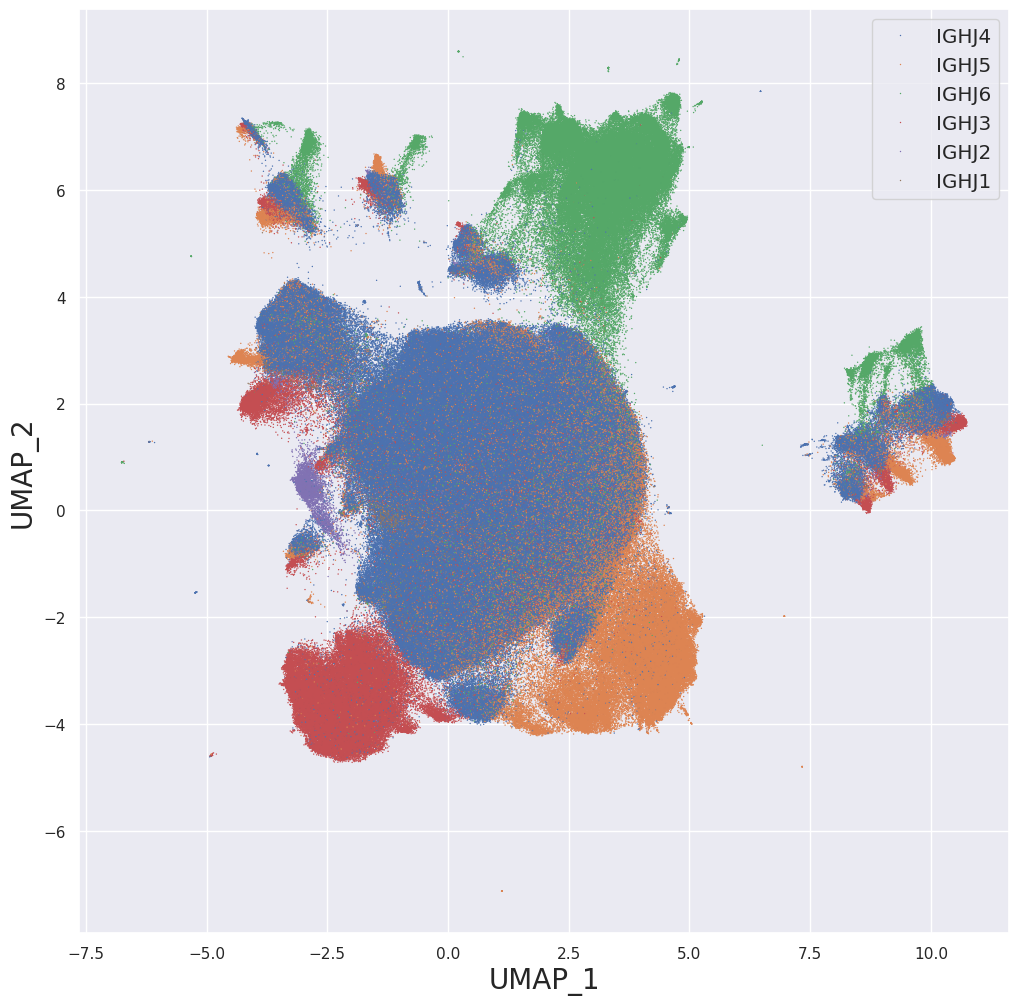

In [56]:
model_name = 'ab2'
red = 'UMAP'
dataset_name = 'ireceptor_h_cdr3'

# Define hue_name
hue_name = 'j_family'

# Create the scatterplot
plt.figure(figsize=(12, 12))
scatter = sns.scatterplot(data=df, x='x', y='y', s=1, linewidth=0, hue=hue_name)

# Set the legend
plt.legend(loc='upper right', bbox_to_anchor=(1, 1), fontsize='large')

# Set axes' names
plt.xlabel(f'{red}_1', fontsize=20)
plt.ylabel(f'{red}_2', fontsize=20)

# Save and show the plot
plt.savefig(f'{model_name}_{red}_{dataset_name}_{hue_name}.png')
plt.show()

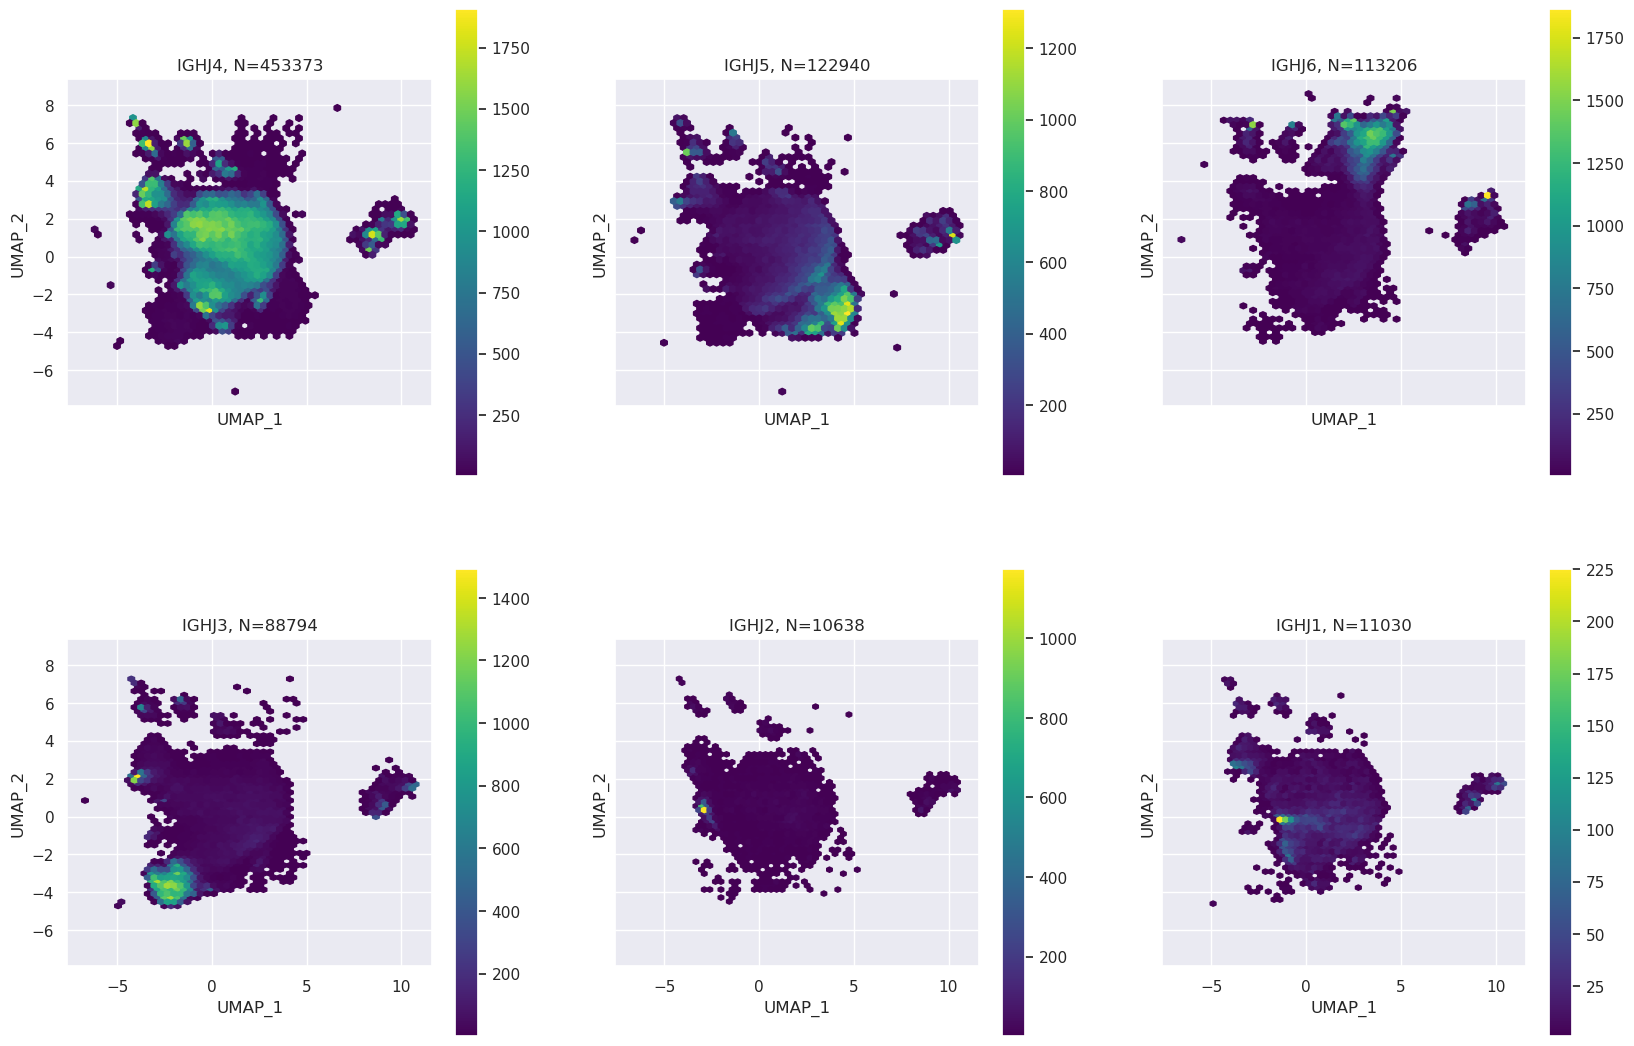

In [59]:
hue_name = 'j_family'

gridsize = 50

# Get the unique classes
unique_classes = df[hue_name].unique()

# Calculate the number of rows and columns based on the number of unique classes
num_classes = len(unique_classes)
num_rows = int(num_classes**0.5)
num_cols = (num_classes + num_rows - 1) // num_rows

# Calculate the figure size to fit the square subplots and maintain the overall aspect ratio
fig_width = 20
fig_height = 20 * (num_rows / num_cols)

# Create a grid of subplots with equal aspect ratio
fig, axes = plt.subplots(num_rows, num_cols, figsize=(fig_width, fig_height), sharex=True, sharey=True)

# Flatten the axes array for easy iteration
axes = axes.flatten()

# Loop through the unique classes and create hexbin plots with titles
for i, el in enumerate(unique_classes):
    ax = axes[i]
    x_data = df[df[hue_name] == el]['x']
    y_data = df[df[hue_name] == el]['y']

    # Set the aspect ratio to be equal (square)
    ax.set_aspect('equal')

    num_data_points = len(x_data)

    # Create a hexbin plot
    hb = ax.hexbin(x_data, y_data, gridsize=gridsize, mincnt=1, cmap='viridis')

    ax.set_title(f'{el}, N={num_data_points}')
    ax.set_xlabel(f'{red}_1', fontsize=12)
    ax.set_ylabel(f'{red}_2', fontsize=12)

    plt.colorbar(hb, ax=ax)  # Add colorbar

# Remove any empty subplots if the number of plots doesn't fill the grid
for i in range(num_classes, num_rows * num_cols):
    fig.delaxes(axes[i])

# Adjust layout to remove the gap between rows and columns
#plt.subplots_adjust(hspace=0, wspace=0)

# Display the plot
plt.savefig(f'{model_name}_{red}_{dataset_name}_hexbin_sep_by_{hue_name}.png')
plt.show()

/tmp/ipykernel_153058/1671265092.py:8: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  original_cmap = cm.get_cmap(cmap_name)
/tmp/ipykernel_153058/1671265092.py:22: MatplotlibDeprecationWarning: Unable to determine Axes to steal space for Colorbar. Using gca(), but will raise in the future. Either provide the *cax* argument to use as the Axes for the Colorbar, provide the *ax* argument to steal space from it, or add *mappable* to an Axes.
  cbar = plt.colorbar(sm, label=hue_name)


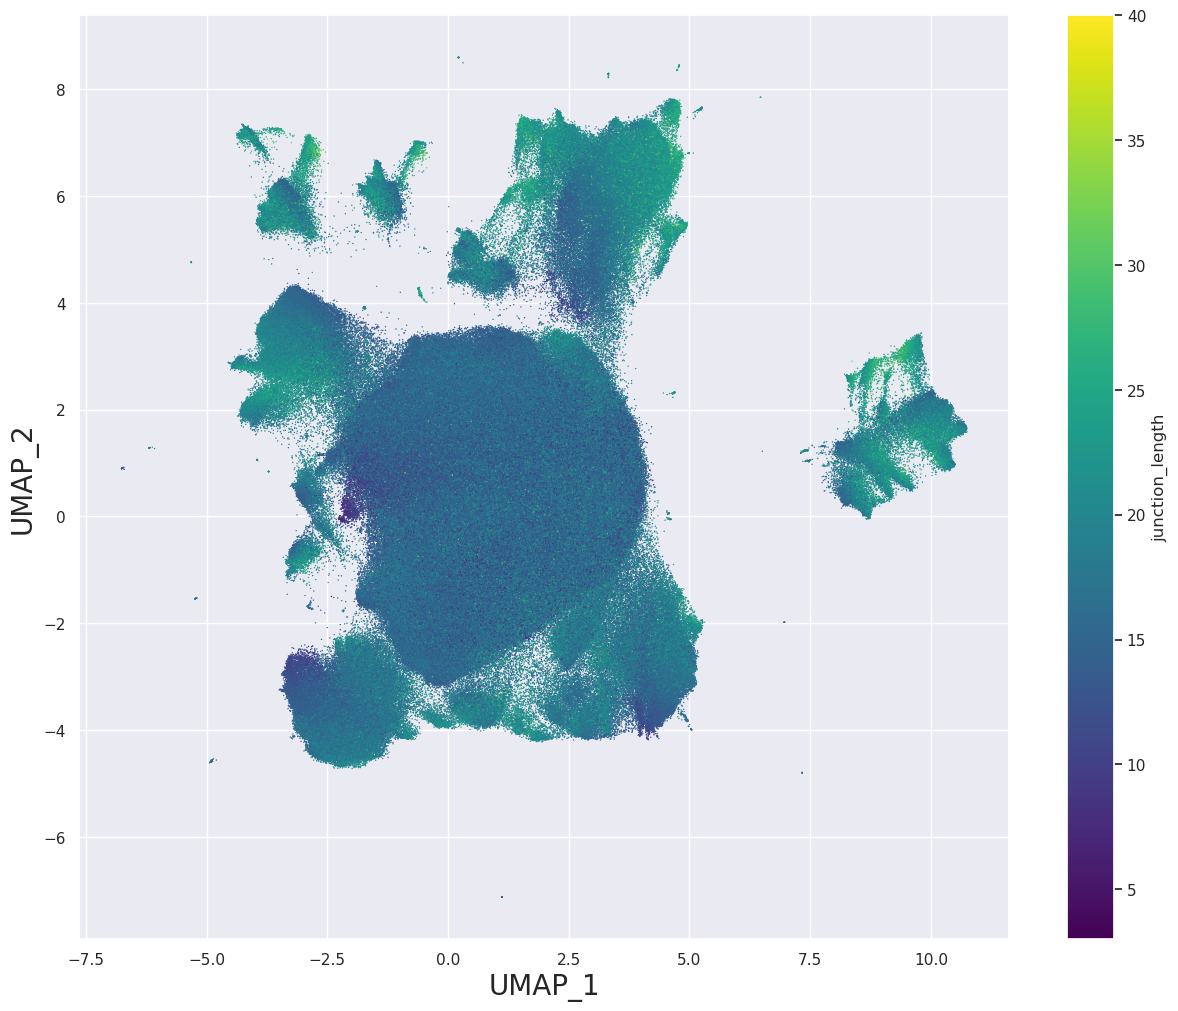

In [7]:
hue_name = 'junction_length'
cmap_name = 'viridis'

red = 'UMAP'
model_name = 'ab2'
dataset_name = 'h_cdr3_ireceptor'

original_cmap = cm.get_cmap(cmap_name)

# Reverse the colormap
reversed_cmap = original_cmap #mcolors.ListedColormap(original_cmap.colors[::-1])

# Create the scatterplot
plt.figure(figsize=(15, 12))
scatter = sns.scatterplot(data=df, x='x', y='y', s=1, linewidth=0, c=df[hue_name], cmap=reversed_cmap)

# Create a ScalarMappable for the colorbar
sm = cm.ScalarMappable(cmap=reversed_cmap, norm=plt.Normalize(vmin=df[hue_name].min(), vmax=df[hue_name].max()))
sm.set_array([])  # You need to set an empty array for it to work

# Add a colorbar for 'mu_freq_heavy'
cbar = plt.colorbar(sm, label=hue_name)

# Set axes' names
plt.xlabel(f'{red}_1', fontsize=20)
plt.ylabel(f'{red}_2', fontsize=20)

# Save and show the plot
plt.savefig(f'{model_name}_{red}_{dataset_name}_{hue_name}.png')
plt.show()

In [102]:
random_umap_df = pd.DataFrame(pd.read_pickle(f'<UPDATE_PATH>'  # TODO: update path to your data).values)
random_umap_df.columns = ['x', 'y']
random_umap_df['index'] = range(0, len(random_umap_df))

random_umap_df

,x,y,index
0,2.312739,1.886970,0
1,2.177915,0.190949,1
2,1.092539,2.496527,2
3,5.074128,4.453261,3
4,5.548354,0.267189,4
...,...,...,...
789995,7.269448,1.392581,789995
789996,1.183177,4.833049,789996
789997,4.093495,1.547683,789997
789998,1.354122,2.864898,789998


In [94]:
ids_csv = pd.read_csv('<UPDATE_PATH>'  # TODO: update path to your data)
ids_csv

,index,sequence_id
0,0,1
1,1,2
2,2,3
3,3,4
4,4,5
...,...,...
789995,789995,789996
789996,789996,789997
789997,789997,789998
789998,789998,789999


In [95]:
random_umap_df = random_umap_df.merge(ids_df[['index', 'sequence_id']], on='index', how='left')
random_umap_df.rename(columns={'sequence_id': 'id'}, inplace=True)

random_umap_df

,x,y,index,id
0,0.816127,1.687398,0,1
1,1.687427,1.528938,1,2
2,1.432758,2.706851,2,3
3,4.436308,4.953733,3,4
4,5.269042,2.057409,4,5
...,...,...,...,...
789995,5.661212,0.010923,789995,789996
789996,1.086773,5.401717,789996,789997
789997,3.478136,1.670650,789997,789998
789998,1.015102,3.790273,789998,789999


In [96]:
random_df = pd.read_csv('<UPDATE_PATH>'  # TODO: update path to your data)
random_df.rename(columns={'seq_id': 'id'}, inplace=True)
random_df

,id,sequence_aa,batch
0,1,CGNPKLNGSATW,batch_0
1,2,CCPIQHWGWNMRWFLVW,batch_0
2,3,CAQLLICAVKQYSW,batch_0
3,4,CMKIEHVEFVNPTW,batch_0
4,5,CQYLWSAFSDIKLEIFGYHKAW,batch_0
...,...,...,...
789995,789996,CYFSKHHRANQWEYCFSVHYRW,batch_0
789996,789997,CHHLAKCQPMLTIMNTQQQW,batch_0
789997,789998,CRYGGWMVMTDSMKWMW,batch_0
789998,789999,CMTTWFEREGPSMEDWIW,batch_0


In [98]:
random_df = random_df.merge(random_umap_df, on='id', how='left')
random_df['junction_length'] = random_df['sequence_aa'].str.len()
random_df

,id,sequence_aa,batch,x,y,index,junction_length
0,1,CGNPKLNGSATW,batch_0,0.816127,1.687398,0,12
1,2,CCPIQHWGWNMRWFLVW,batch_0,1.687427,1.528938,1,17
2,3,CAQLLICAVKQYSW,batch_0,1.432758,2.706851,2,14
3,4,CMKIEHVEFVNPTW,batch_0,4.436308,4.953733,3,14
4,5,CQYLWSAFSDIKLEIFGYHKAW,batch_0,5.269042,2.057409,4,22
...,...,...,...,...,...,...,...
789995,789996,CYFSKHHRANQWEYCFSVHYRW,batch_0,5.661212,0.010923,789995,22
789996,789997,CHHLAKCQPMLTIMNTQQQW,batch_0,1.086773,5.401717,789996,20
789997,789998,CRYGGWMVMTDSMKWMW,batch_0,3.478136,1.670650,789997,17
789998,789999,CMTTWFEREGPSMEDWIW,batch_0,1.015102,3.790273,789998,18


/tmp/ipykernel_114013/231540678.py:4: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  original_cmap = cm.get_cmap(cmap_name)
/tmp/ipykernel_114013/231540678.py:18: MatplotlibDeprecationWarning: Unable to determine Axes to steal space for Colorbar. Using gca(), but will raise in the future. Either provide the *cax* argument to use as the Axes for the Colorbar, provide the *ax* argument to steal space from it, or add *mappable* to an Axes.
  cbar = plt.colorbar(sm, label=hue_name)


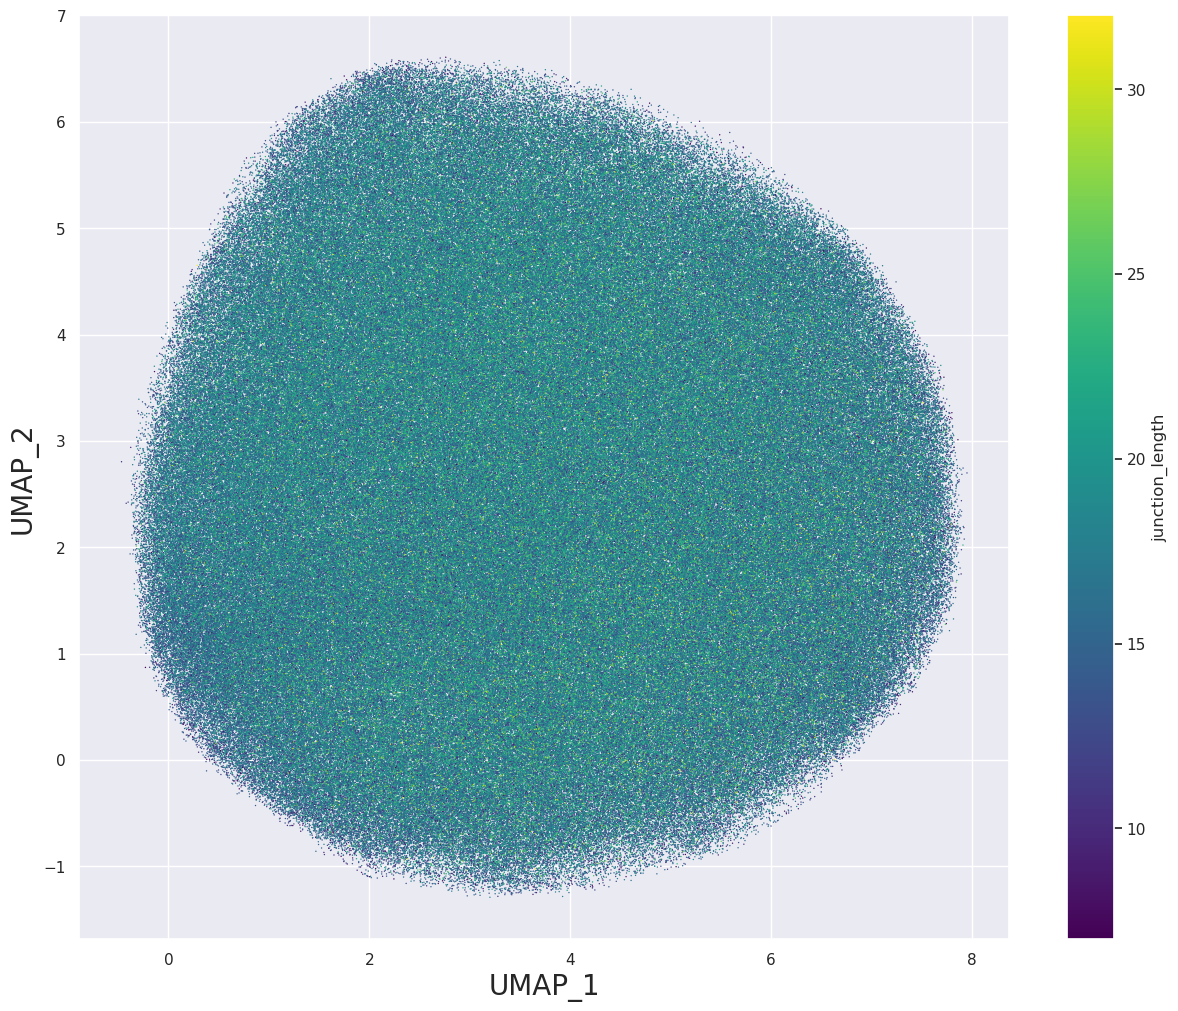

In [99]:
hue_name = 'junction_length'
cmap_name = 'viridis'

original_cmap = cm.get_cmap(cmap_name)

# Reverse the colormap
reversed_cmap = original_cmap #mcolors.ListedColormap(original_cmap.colors[::-1])

# Create the scatterplot
plt.figure(figsize=(15, 12))
scatter = sns.scatterplot(data=random_df, x='x', y='y', s=1, linewidth=0, c=random_df[hue_name], cmap=reversed_cmap)

# Create a ScalarMappable for the colorbar
sm = cm.ScalarMappable(cmap=reversed_cmap, norm=plt.Normalize(vmin=random_df[hue_name].min(), vmax=random_df[hue_name].max()))
sm.set_array([])  # You need to set an empty array for it to work

# Add a colorbar for 'mu_freq_heavy'
cbar = plt.colorbar(sm, label=hue_name)

# Set axes' names
plt.xlabel(f'{red}_1', fontsize=20)
plt.ylabel(f'{red}_2', fontsize=20)

# Save and show the plot
plt.savefig(f'{model_name}_{red}_{dataset_name}_{hue_name}.png')
plt.show()

<Axes: xlabel='x', ylabel='y'>

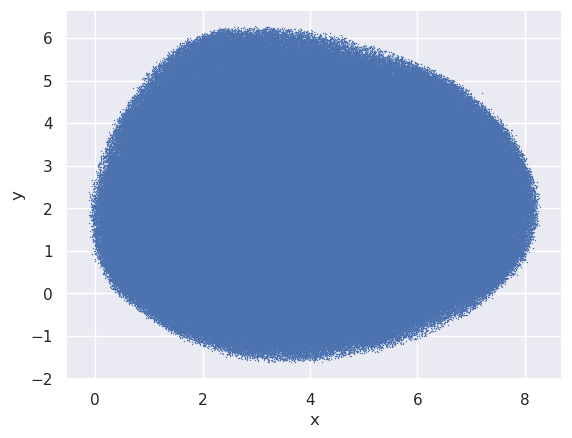

In [103]:
sns.scatterplot(data=random_umap_df, x='x', y='y', s=1, linewidth=0)